In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from lo_tools import Lfun, zrfun, zfun
Ldir = Lfun.Lstart()

In [34]:
# open the initial condition file
fn = "../../LO_output/forcing/ae0/f2020.01.01/ocnA0grdnt/ocean_ini.nc" 
ds = xr.open_dataset(fn)

print(ds)

<xarray.Dataset> Size: 132MB
Dimensions:     (ocean_time: 1, eta_rho: 386, xi_rho: 348, eta_u: 386,
                 xi_u: 347, eta_v: 385, xi_v: 348, s_rho: 30)
Coordinates:
  * ocean_time  (ocean_time) datetime64[ns] 8B 2020-01-01
Dimensions without coordinates: eta_rho, xi_rho, eta_u, xi_u, eta_v, xi_v, s_rho
Data variables:
    zeta        (ocean_time, eta_rho, xi_rho) float64 1MB ...
    ubar        (ocean_time, eta_u, xi_u) float64 1MB ...
    vbar        (ocean_time, eta_v, xi_v) float64 1MB ...
    salt        (ocean_time, s_rho, eta_rho, xi_rho) float64 32MB ...
    temp        (ocean_time, s_rho, eta_rho, xi_rho) float64 32MB ...
    u           (ocean_time, s_rho, eta_u, xi_u) float64 32MB ...
    v           (ocean_time, s_rho, eta_v, xi_v) float64 32MB ...


In [35]:
print(ds['salt'][0,-1,:,:].min().values, ds['salt'][0,-1,:,:].max().values)
ds.close()

0.0 30.0


In [36]:
surf = ds["salt"][0, -1, :, :].values  # surface at time 0
mid = surf.shape[0] // 2
transect = surf[mid, :]

print("Surface centerline salinity transect:")
print(transect)

ds.close()

Surface centerline salinity transect:
[30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.         30.
 30.         30.         30.         30.         30.

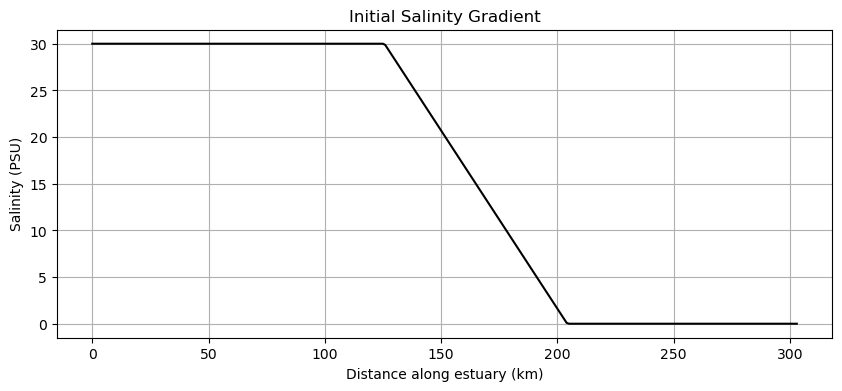

In [37]:
# Extract surface salinity (first time, surface layer)
salt = ds['salt'][0, -1, :, :].values# (eta, xi)

mid = salt.shape[0]//2

salt1d = salt[mid, :]

x = np.arange(salt1d.size)  # distance in km (assuming 1 km grid spacing)

plt.figure(figsize=(10,4))
plt.plot(x, salt1d, '-k', lw=1.5)
plt.xlabel('Distance along estuary (km)')
plt.ylabel('Salinity (PSU)')
plt.title('Initial Salinity Gradient')
plt.grid(True)
plt.show()

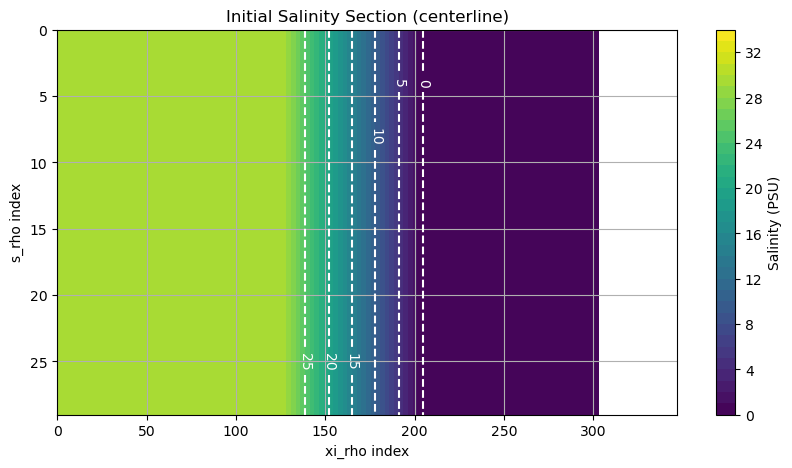

In [39]:

# Extract salt
salt = ds['salt'][0, :, :, :]  # shape (s_rho, eta_rho, xi_rho)

# Pick centerline along eta_rho
jmid = salt.shape[1] // 2
salt_sect = salt[:, jmid, :]  # (s_rho, xi_rho)

# Axes (just indices)
x = np.arange(salt_sect.shape[1])  # xi_rho index
z = np.arange(salt_sect.shape[0])  # s_rho index

# Make 2D arrays for contourf
X, Z = np.meshgrid(x, z)

# Plot
plt.figure(figsize=(10,5))
cf = plt.contourf(X, Z, salt_sect, levels=np.arange(0,35,1), cmap='viridis')
plt.colorbar(cf, label='Salinity (PSU)')

# Overlay constant salinity lines
cs = plt.contour(X, Z, salt_sect, levels=np.arange(0,35,5), colors='white', linestyles='--')
plt.clabel(cs, fmt='%1.0f', colors='white')

plt.xlabel('xi_rho index')
plt.ylabel('s_rho index')
plt.title('Initial Salinity Section (centerline)')
plt.gca().invert_yaxis()  # Optional: invert vertical axis to match ROMS plotting
plt.grid(True)
plt.show()

ds.close()